In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox,het_arch,het_breuschpagan
import statsmodels.api as sm
from arch import arch_model
from statsmodels.stats.outliers_influence import variance_inflation_factor

import itertools
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("delhi_ncr_aqi_dataset.csv")

df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

# Keep only relevant columns
df = df[['city','station','pm25','pm10','no2','so2','co','o3',
         'temperature','humidity','wind_speed','visibility','aqi']]

# Interpolate missing values (time-aware)
df = df.interpolate(method='time')
selected_stations=[
    'NSIT Dwarka, Delhi',
    'Mandir Marg, Delhi', 
    'Dwarka Sec 8, Delhi',
    'Greater Noida',
    'Siri Fort, Delhi'
]
df = df[df['station'].isin(selected_stations)]
df.dropna(inplace=True)

In [3]:
np.random.seed(42)

# Replace AQI == 500 with random values between 510 and 600
mask = df['aqi'] == 500
df.loc[mask, 'aqi'] = np.random.randint(480, 580, size=mask.sum())

# ================================================================
# 🔷 Verify
# ================================================================
print("📊 After replacement:")
print(df.groupby('station')['aqi'].agg(['min', 'max', 'mean', 'count']).round(2))

print("\n📊 Remaining values at exactly 500:")
print(df.groupby('station')['aqi'].apply(lambda x: (x == 500).sum()))

print("\n📊 Values between 550-600:")
print(df.groupby('station')['aqi'].apply(lambda x: ((x >= 500) & (x <= 580)).sum()))

📊 After replacement:
                     min  max    mean  count
station                                     
Dwarka Sec 8, Delhi   25  579  253.15   8768
Greater Noida         25  579  253.65   8768
Mandir Marg, Delhi    25  579  253.15   8768
NSIT Dwarka, Delhi    25  579  249.54   8768
Siri Fort, Delhi      25  579  256.73   8768

📊 Remaining values at exactly 500:
station
Dwarka Sec 8, Delhi    15
Greater Noida          21
Mandir Marg, Delhi     20
NSIT Dwarka, Delhi     20
Siri Fort, Delhi       17
Name: aqi, dtype: int64

📊 Values between 550-600:
station
Dwarka Sec 8, Delhi    1235
Greater Noida          1258
Mandir Marg, Delhi     1217
NSIT Dwarka, Delhi     1147
Siri Fort, Delhi       1292
Name: aqi, dtype: int64


In [4]:
df.head(15)

,city,station,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
datetime,,,,,,,,,,,,,
2020-01-01 06:00:00,Delhi,"Mandir Marg, Delhi",248.2,424.5,94.7,16.4,4.38,24.5,8.3,100,3.6,1.7,399
2020-01-01 06:00:00,Delhi,"NSIT Dwarka, Delhi",327.0,596.1,111.2,22.6,5.13,15.2,9.9,100,2.2,1.3,531
2020-01-01 06:00:00,Delhi,"Dwarka Sec 8, Delhi",269.8,488.6,89.8,15.9,4.23,21.5,7.4,100,3.4,2.6,473
2020-01-01 06:00:00,Noida,Greater Noida,305.5,642.7,121.3,31.4,3.70,17.7,7.7,95,2.7,1.1,572
2020-01-01 06:00:00,Delhi,"Siri Fort, Delhi",307.6,649.7,107.7,23.7,4.67,14.6,6.8,100,3.7,1.4,494
2020-01-01 12:00:00,Delhi,"Dwarka Sec 8, Delhi",217.9,440.9,64.4,21.3,3.14,24.5,19.0,64,7.4,2.4,414
2020-01-01 12:00:00,Delhi,"NSIT Dwarka, Delhi",231.1,436.6,95.0,18.3,3.92,25.1,17.2,46,9.9,2.6,408
2020-01-01 12:00:00,Delhi,"Siri Fort, Delhi",208.2,338.9,64.7,11.8,3.38,29.0,19.6,65,10.4,3.0,368
2020-01-01 12:00:00,Noida,Greater Noida,243.2,498.7,100.1,23.8,3.25,22.6,17.8,46,7.0,2.1,486


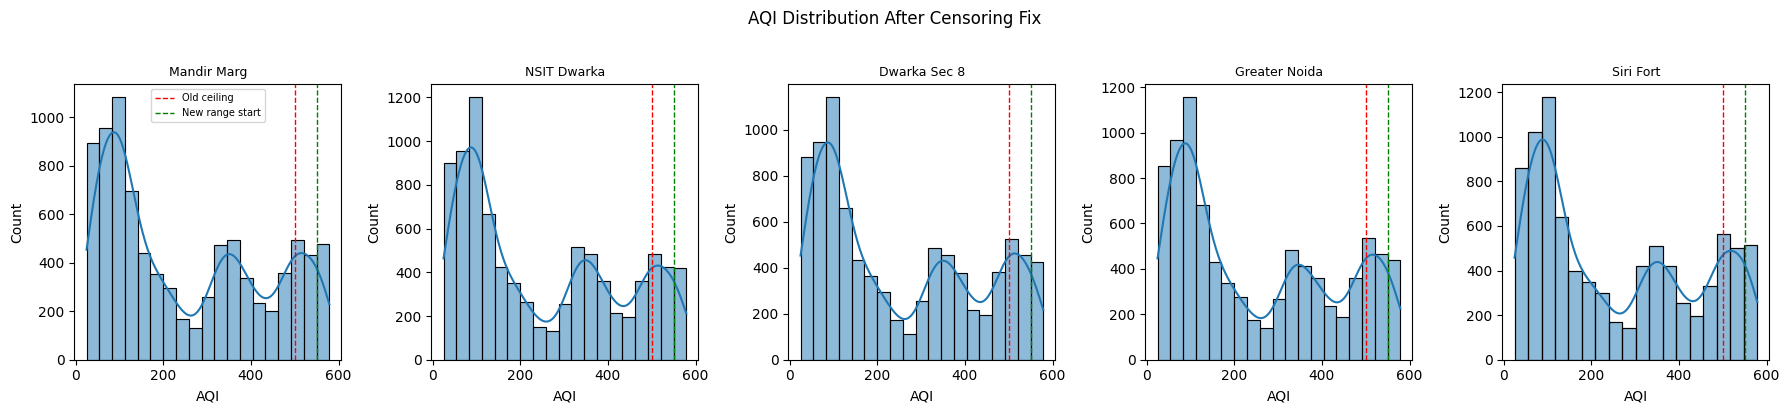

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, station in zip(axes, df['station'].unique()):
    ts = df[df['station'] == station]['aqi']
    sns.histplot(ts, kde=True, ax=ax)
    ax.axvline(x=500, color='red', linestyle='--', linewidth=1, label='Old ceiling')
    ax.axvline(x=550, color='green', linestyle='--', linewidth=1, label='New range start')
    ax.set_title(station.split(',')[0], fontsize=9)
    ax.set_xlabel('AQI')

axes[0].legend(fontsize=7)
plt.suptitle('AQI Distribution After Censoring Fix', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
df['station'].describe()

count                  43840
unique                     5
top       Mandir Marg, Delhi
freq                    8768
Name: station, dtype: object

In [7]:
df.describe()

,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
count,43840.000000,43840.000000,43840.000000,43840.000000,43840.000000,43840.000000,43840.000000,43840.000000,43840.000000,43840.000000,43840.000000
mean,165.374656,314.290577,62.955347,13.616515,2.734916,27.648812,26.889585,61.062021,10.548634,5.403488,253.242313
std,179.150878,342.346797,70.401030,14.472193,3.038117,13.414748,8.988679,24.742281,6.069241,3.784314,177.844728
min,15.000000,24.000000,8.000000,4.000000,0.300000,12.000000,6.000000,20.000000,2.100000,0.200000,25.000000
25%,49.600000,93.300000,17.900000,4.000000,0.780000,19.000000,19.900000,39.000000,5.900000,2.200000,94.000000
50%,88.900000,169.200000,33.900000,7.200000,1.500000,23.700000,27.600000,58.000000,9.200000,4.800000,196.000000
75%,228.800000,432.300000,84.100000,17.800000,3.690000,32.300000,33.500000,83.000000,14.300000,7.500000,405.000000
max,900.000000,1978.000000,584.600000,93.500000,22.660000,84.000000,44.800000,100.000000,31.500000,15.000000,579.000000


In [8]:
df.isna().sum()

city           0
station        0
pm25           0
pm10           0
no2            0
so2            0
co             0
o3             0
temperature    0
humidity       0
wind_speed     0
visibility     0
aqi            0
dtype: int64

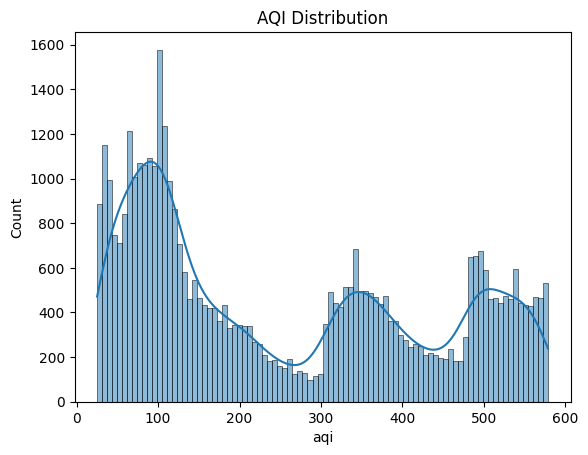

In [9]:
sns.histplot(df['aqi'], bins=90, kde=True)
plt.title("AQI Distribution")
plt.show()

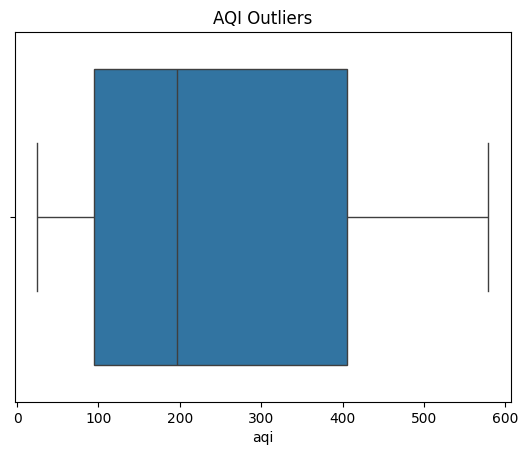

In [10]:
sns.boxplot(x=df['aqi'])
plt.title("AQI Outliers")
plt.show()

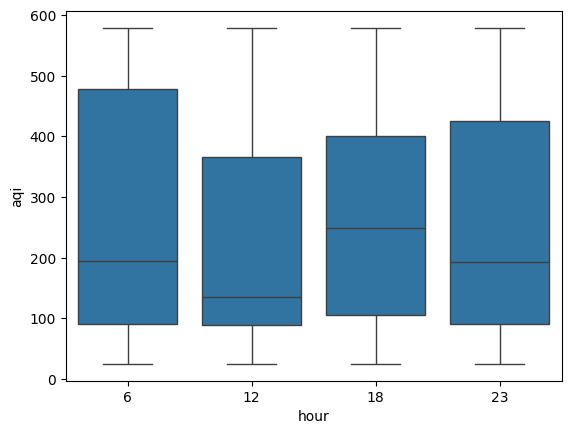

In [11]:
df['hour'] = df.index.hour
sns.boxplot(x='hour', y='aqi', data=df)
plt.show()

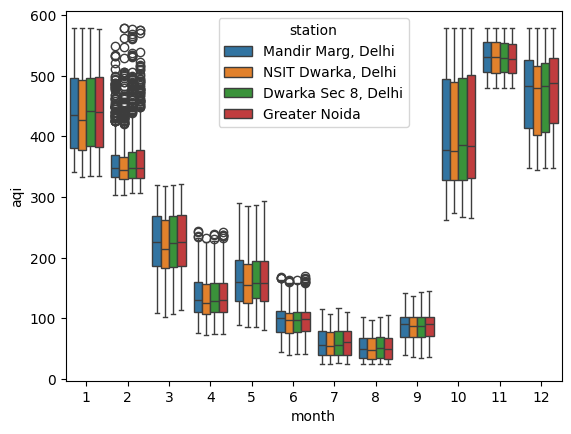

In [15]:
selected_stations=[
    'NSIT Dwarka, Delhi',
    'Mandir Marg, Delhi', 
    'Dwarka Sec 8, Delhi',
    'Greater Noida'
]
df_filtered = df[df['station'].isin(selected_stations)].copy()
df_filtered['month'] = df_filtered.index.month

sns.boxplot(x='month', y='aqi', hue='station', data=df_filtered)
plt.show()

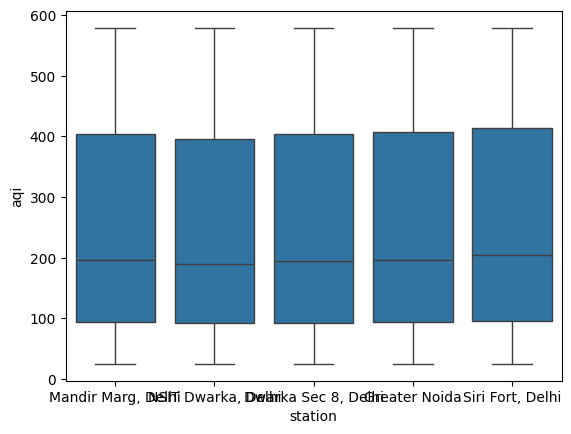

In [16]:
sns.boxplot(x='station', y='aqi', data=df)
plt.show()

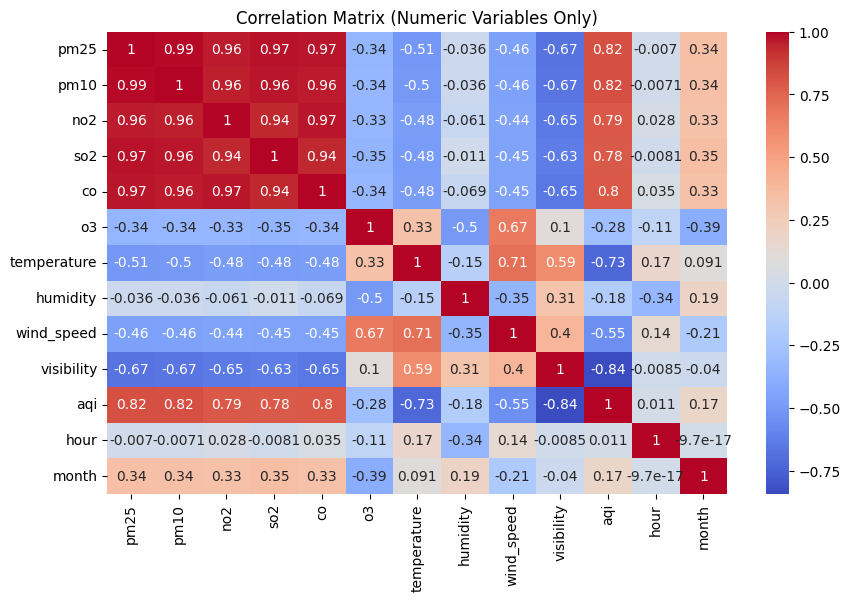

In [17]:
num_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Matrix (Numeric Variables Only)")
plt.show()

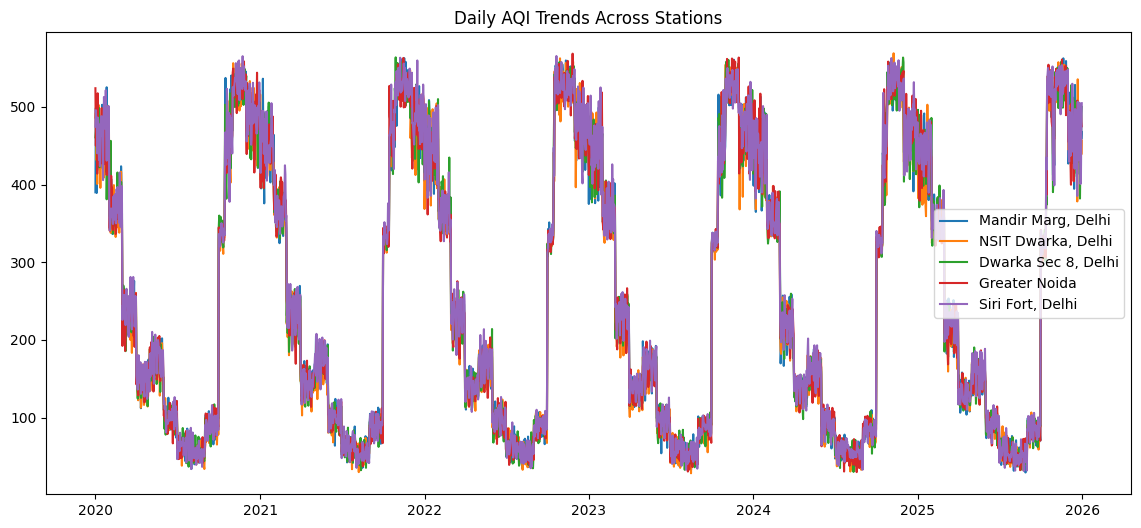

In [18]:
plt.figure(figsize=(14,6))

for city in df['station'].unique():
    temp = df[df['station']==city]['aqi'].resample('D').mean()
    plt.plot(temp, label=city)

plt.legend()
plt.title("Daily AQI Trends Across Stations")
plt.show()

In [19]:
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()['aqi'].sort_values(ascending=False)
print(corr)

aqi            1.000000
pm25           0.821068
pm10           0.820844
co             0.796455
no2            0.792925
so2            0.784243
month          0.173755
hour           0.011248
humidity      -0.175181
o3            -0.284533
wind_speed    -0.552763
temperature   -0.725869
visibility    -0.842166
Name: aqi, dtype: float64


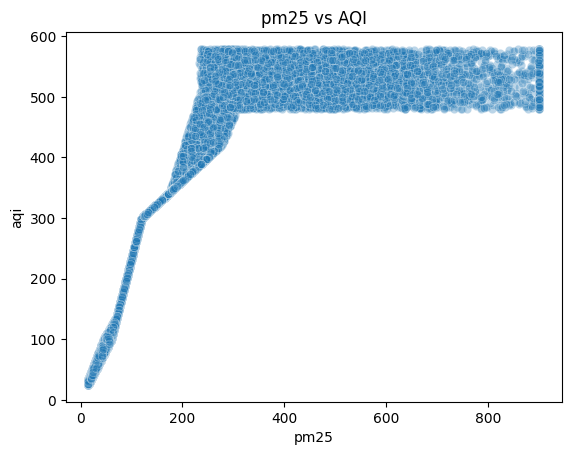

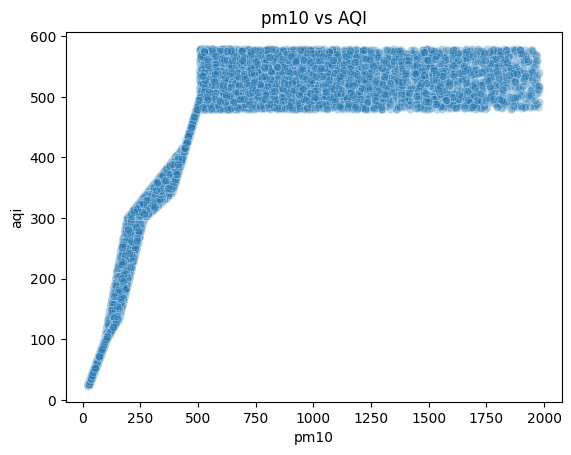

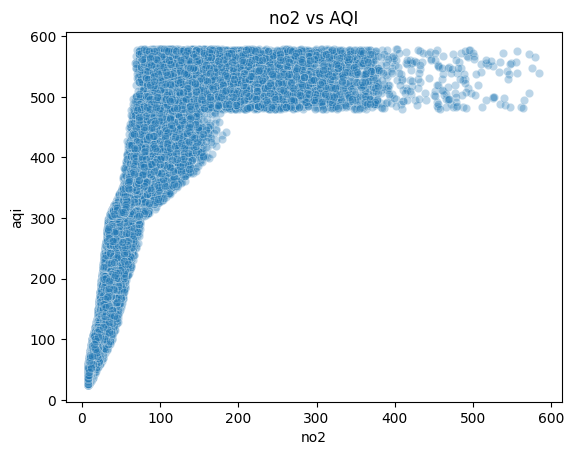

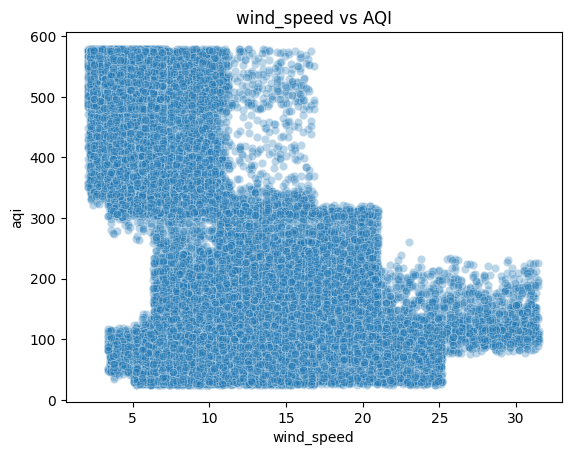

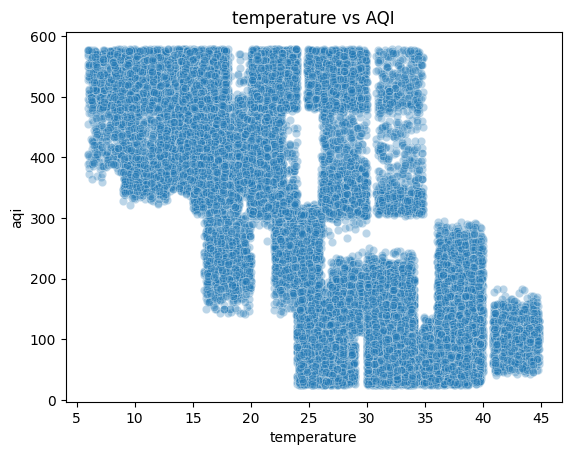

In [20]:
important_features = ['pm25','pm10','no2','wind_speed','temperature']

for col in important_features:
    sns.scatterplot(x=df[col], y=df['aqi'], alpha=0.3)
    plt.title(f"{col} vs AQI")
    plt.show()

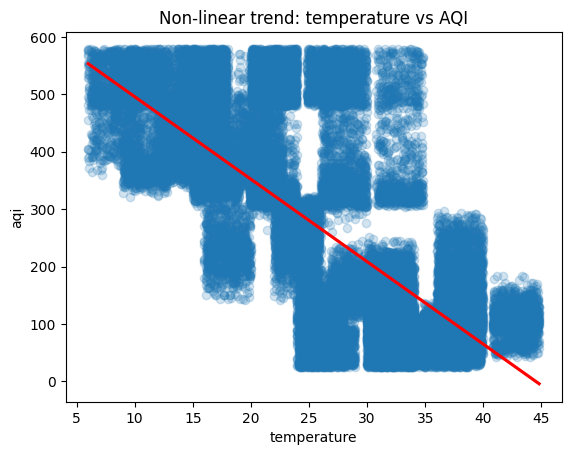

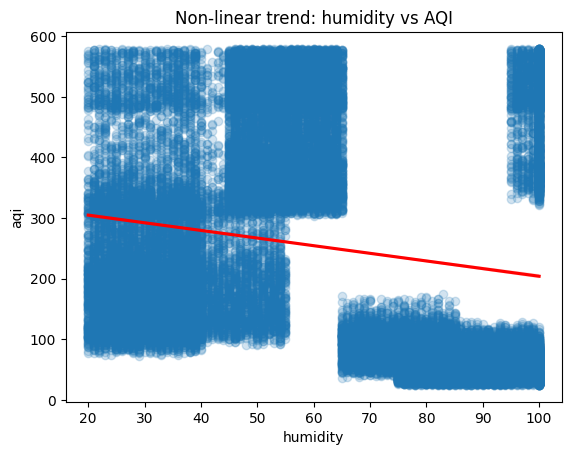

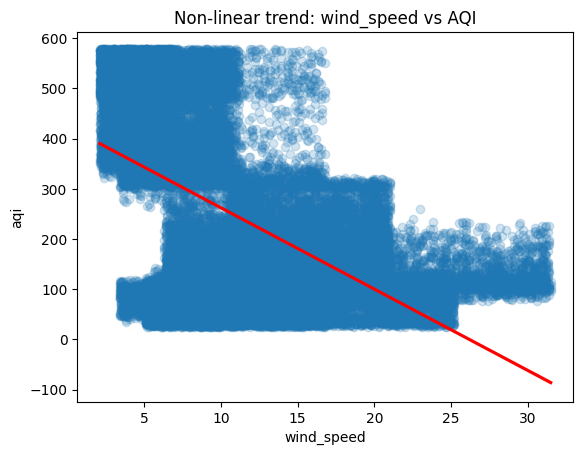

In [21]:
for col in ['temperature','humidity','wind_speed']:
    sns.regplot(x=df[col], y=df['aqi'],
                scatter_kws={'alpha':0.2},
                line_kws={'color':'red'})
    plt.title(f"Non-linear trend: {col} vs AQI")
    plt.show()

In [22]:
X = num_df.drop('aqi', axis=1)

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif.sort_values('VIF', ascending=False))

        Feature         VIF
0          pm25  192.086090
1          pm10  123.137628
4            co   39.723652
2           no2   34.948016
3           so2   34.623509
6   temperature   28.625262
8    wind_speed   14.327399
9    visibility    9.049697
5            o3    8.402096
7      humidity    7.713834
11        month    7.103721
10         hour    5.952033


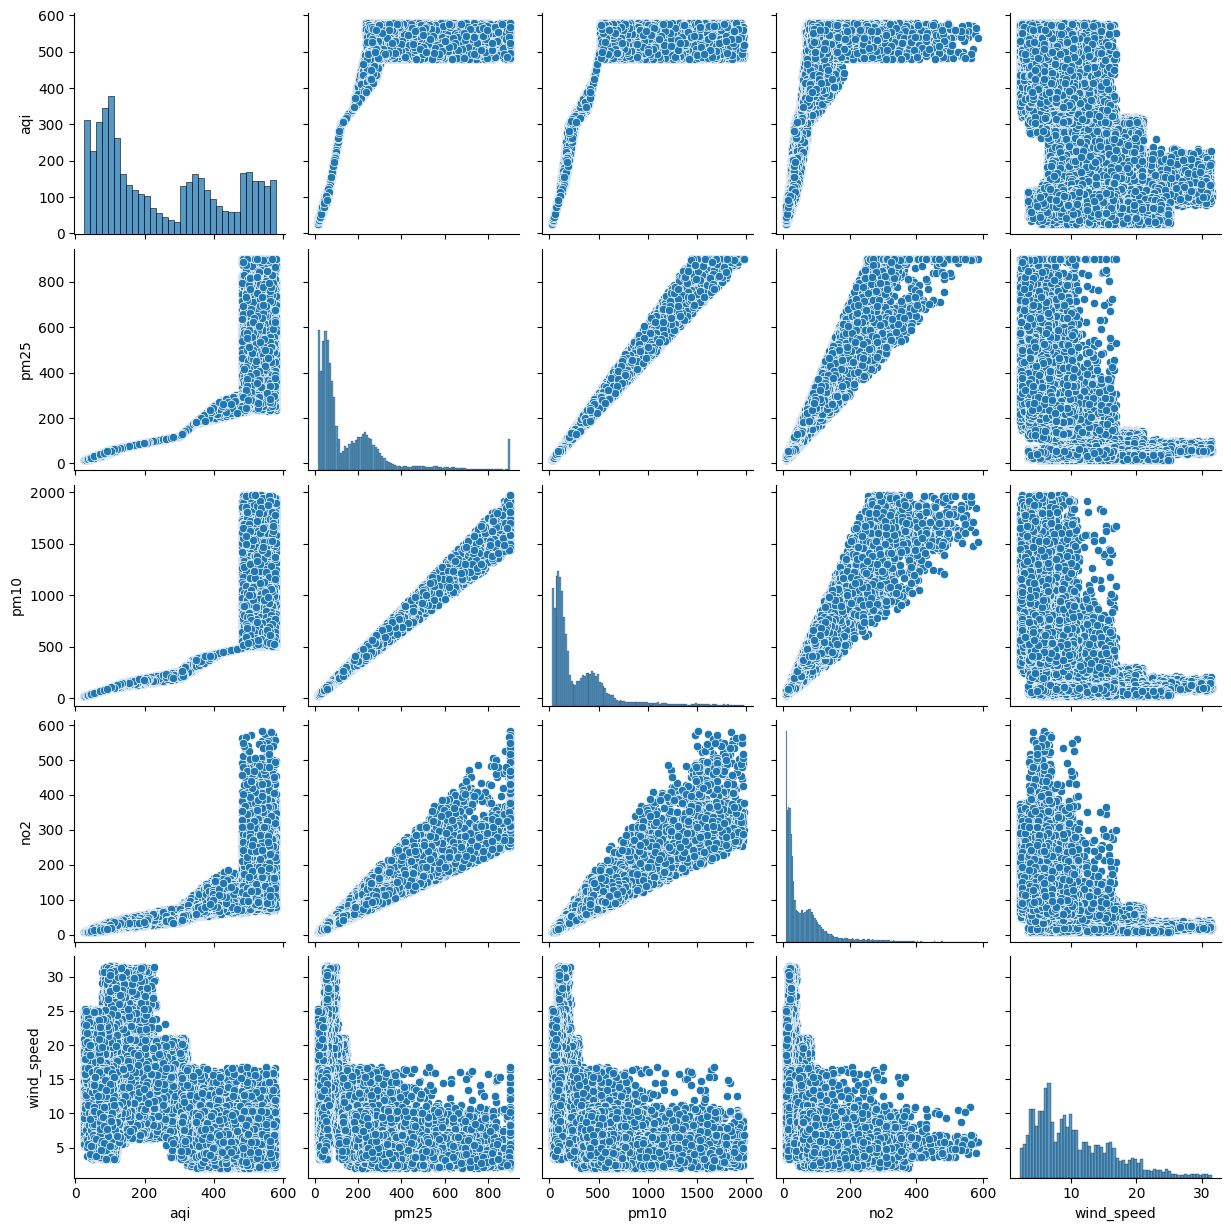

In [23]:
sns.pairplot(df[['aqi','pm25','pm10','no2','wind_speed']])
plt.show()

In [24]:
for station in df['station'].unique():
    features = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
                'temperature', 'humidity', 'wind_speed', 'visibility']

    data = df[df['station'] == station][['aqi'] + features].dropna()
    print(f'Station name: {station}')

    # ================================================================
    # 🔷 1. Correlation with AQI
    # ================================================================
    corr = data.corr()['aqi'].drop('aqi').sort_values(ascending=False)
    print("📊 Correlation with AQI:")
    print(corr.round(3))

    # ================================================================
    # 🔷 2. Multicollinearity check (VIF)
    # ================================================================
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    X = data[features].dropna()
    vif = pd.DataFrame({
        'feature': features,
        'VIF'    : [variance_inflation_factor(X.values, i) 
                    for i in range(len(features))]
    }).sort_values('VIF', ascending=False)

    print("\n📊 VIF Scores (>10 = multicollinearity problem):")
    print(vif.to_string(index=False))

    # ================================================================
    # 🔷 3. Granger Causality (does feature Granger-cause AQI?)
    # ================================================================
    from statsmodels.tsa.stattools import grangercausalitytests

    print("\n📊 Granger Causality (p-value, lag=4):")
    for feature in features:
        try:
            test_data = data[['aqi', feature]].dropna()
            result    = grangercausalitytests(test_data, maxlag=4, verbose=False)
            # get min p-value across lags
            min_p = min([result[lag][0]['ssr_ftest'][1] for lag in range(1, 5)])
            print(f"  {feature:15}: p={min_p:.4f} → {'Granger-causes AQI ✅' if min_p < 0.05 else 'No causality ❌'}")
        except:
            print(f"  {feature:15}: Failed")

Station name: Mandir Marg, Delhi
📊 Correlation with AQI:
pm25           0.821
pm10           0.821
co             0.795
no2            0.789
so2            0.783
humidity      -0.172
o3            -0.285
wind_speed    -0.554
temperature   -0.726
visibility    -0.844
Name: aqi, dtype: float64

📊 VIF Scores (>10 = multicollinearity problem):
    feature        VIF
       pm25 186.579372
       pm10 125.615961
         co  38.072153
        so2  36.263263
        no2  32.696272
temperature  20.028641
 wind_speed  14.166418
 visibility   8.940410
         o3   8.171226
   humidity   7.401653

📊 Granger Causality (p-value, lag=4):
  pm25           : p=0.0000 → Granger-causes AQI ✅
  pm10           : p=0.0000 → Granger-causes AQI ✅
  no2            : p=0.0000 → Granger-causes AQI ✅
  so2            : p=0.0000 → Granger-causes AQI ✅
  co             : p=0.0000 → Granger-causes AQI ✅
  o3             : p=0.0000 → Granger-causes AQI ✅
  temperature    : p=0.0000 → Granger-causes AQI ✅
  humidit

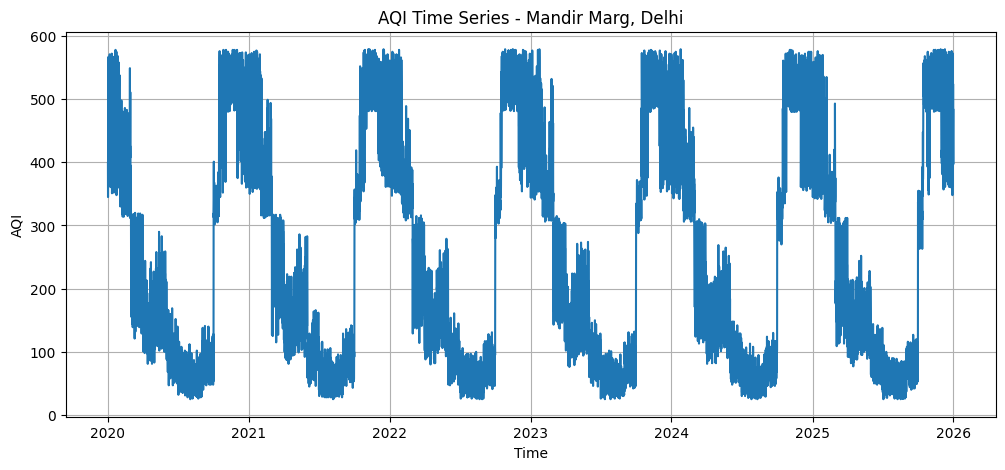

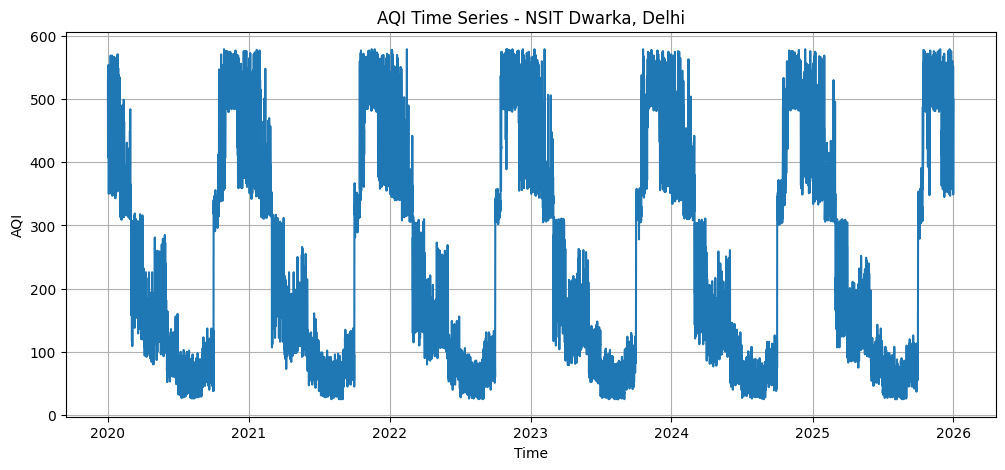

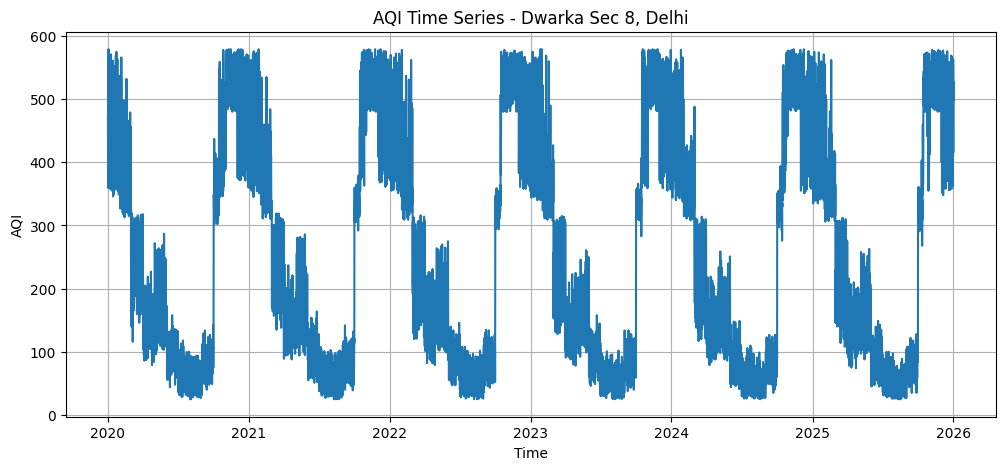

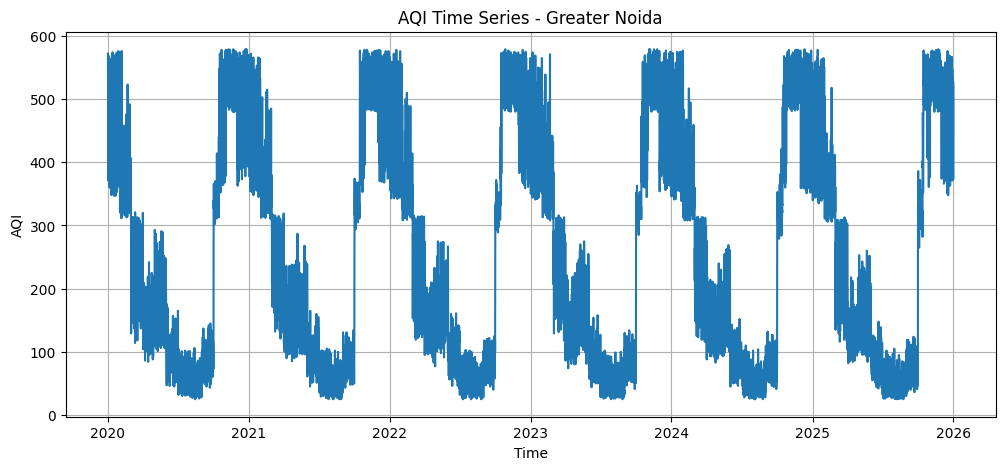

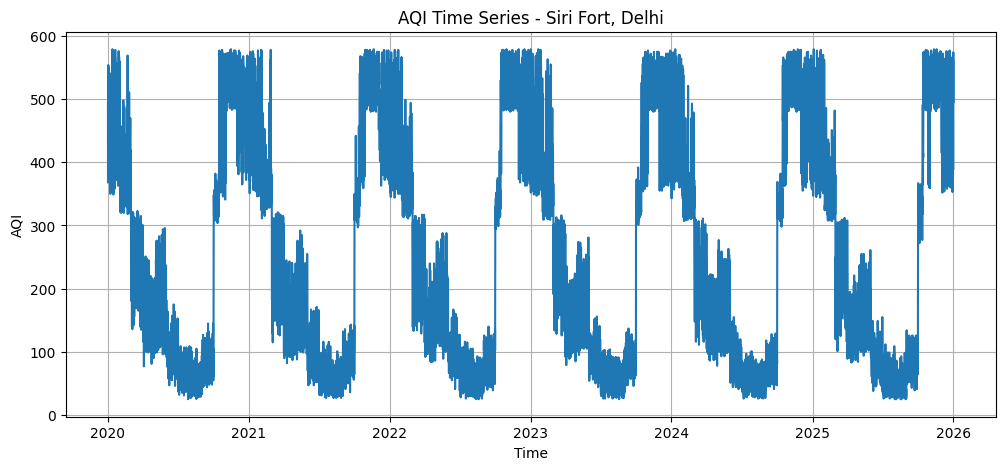

In [25]:
for station in df['station'].unique():
    
    ts = df[df['station'] == station]['aqi']
    
    plt.figure(figsize=(12,5))
    plt.plot(ts)
    
    plt.title(f"AQI Time Series - {station}")
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.grid(True)
    
    plt.show()

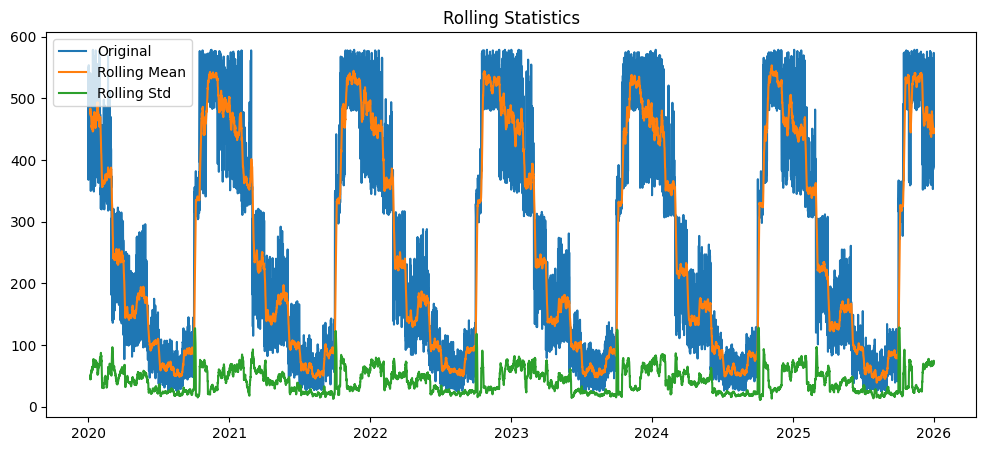

In [26]:
rolling_mean = ts.rolling(window=20).mean()
rolling_std = ts.rolling(window=20).std()

plt.figure(figsize=(12,5))
plt.plot(ts, label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title("Rolling Statistics")
plt.show()

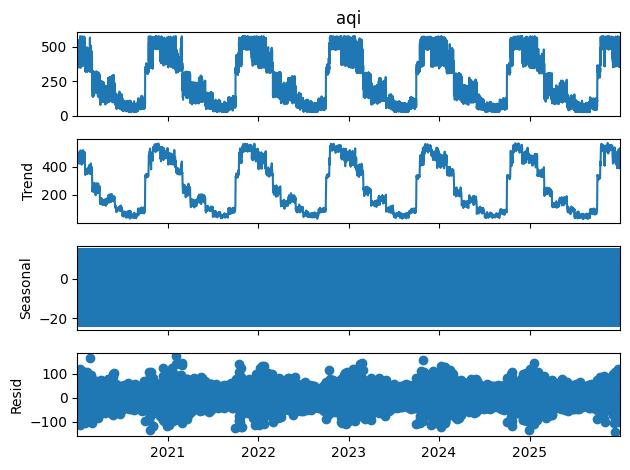

In [27]:
decomp = seasonal_decompose(ts, model='additive', period=4)

decomp.plot()
plt.show()

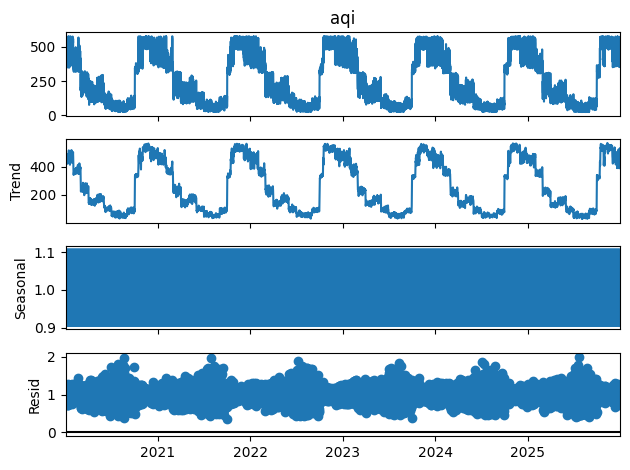

In [28]:
decomp = seasonal_decompose(ts, model='multiplicative', period=4)

decomp.plot()
plt.show()